In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

print("PyTorch version:", torch.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristi se uređaj:", device)

PyTorch version: 2.10.0+cu128
Koristi se uređaj: cuda


In [2]:
# Priprema podataka
train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

# Flattovanje u 1D nizove (784) i normalizacija na 0-1 (preporučljivo za stabilnost)
x_train_pt = train_dataset.data.float().view(-1, 28 * 28) / 255.0
y_train_pt = train_dataset.targets

x_test_pt = test_dataset.data.float().view(-1, 28 * 28) / 255.0
y_test_pt = test_dataset.targets

# Konverzija u NumPy za Scikit-Learn PCA
x_train_np = x_train_pt.numpy()
y_train_np = y_train_pt.numpy()
x_test_np = x_test_pt.numpy()
y_test_np = y_test_pt.numpy()

print(x_train_np.shape, y_train_np.shape, x_test_np.shape, y_test_np.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.44MB/s]


(60000, 784) (60000,) (10000, 784) (10000,)


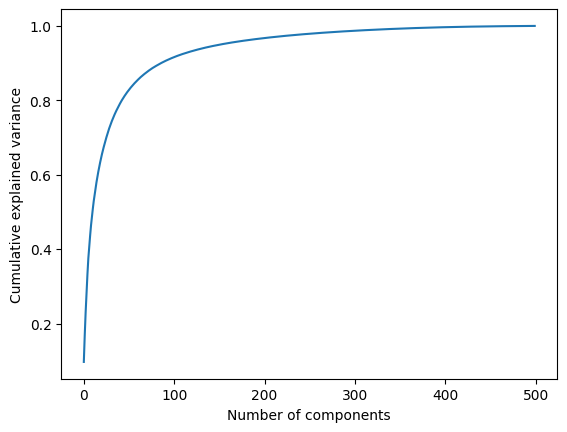

In [3]:
# PCA - analiza za odredjivanje potrebnog broja komponenti
pca = PCA(n_components=500)
pca.fit(x_train_np)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [4]:
# PCA - odredjivanje transformacije i transformacija trening i test ulaznih podataka
pca = PCA(n_components=100)
x_pca_train_np = pca.fit_transform(x_train_np)
x_pca_test_np = pca.transform(x_test_np)
pca_std = np.std(x_pca_train_np)
print(x_pca_train_np.shape, x_pca_test_np.shape)

(60000, 100) (10000, 100)


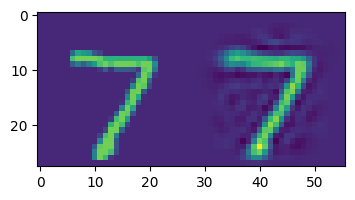

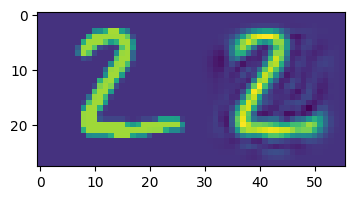

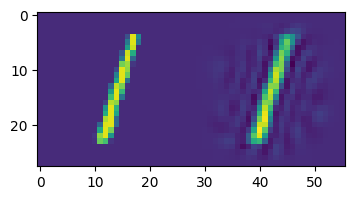

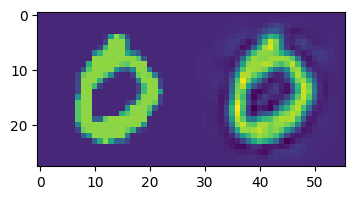

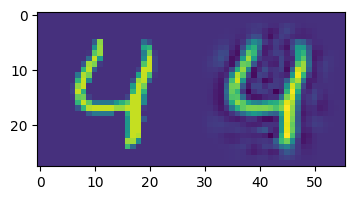

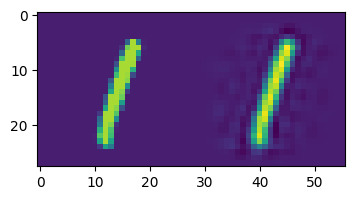

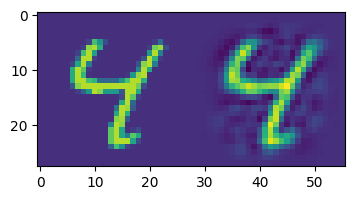

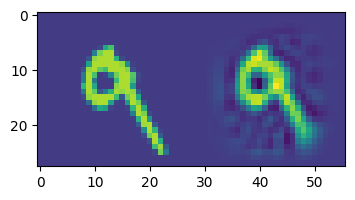

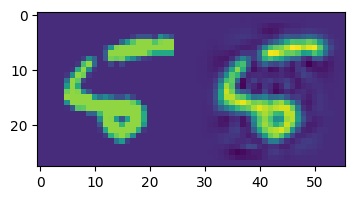

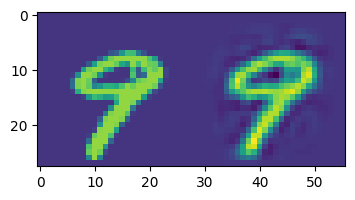

In [5]:
# PCA validacija (inverzna transformacija)
inv_pca_np = pca.inverse_transform(x_pca_test_np)

# Uporedni prikaz originalnih i rekonstruisanih podataka
def side_by_side(indexes):
    org = x_test_np[indexes].reshape(28, 28)
    rec = inv_pca_np[indexes].reshape(28, 28)
    pair = np.concatenate((org, rec), axis=1)
    plt.figure(figsize=(4, 2))
    plt.imshow(pair)
    plt.show()

# Uporedni prikaz 10 slika u cilju validacije broja komponenti
for index in range(0, 10):
    side_by_side(index)

In [6]:
# Povratak iz NumPy u PyTorch tenzore i premeštanje u memoriju uređaja
x_train = torch.tensor(x_pca_train_np, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train_np, dtype=torch.long).to(device)

x_test = torch.tensor(x_pca_test_np, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test_np, dtype=torch.long).to(device)

In [7]:
# Kreiranje MLP modela
class PCAMLPModel(nn.Module):
    def __init__(self):
        super(PCAMLPModel, self).__init__()
        self.net = nn.Sequential(
            # Ulazna dimenzija je 100 (izlaz iz PCA)
            nn.Linear(100, 256),
            nn.Tanh(),
            nn.Linear(256, 10)
            # Softmax je izostavljen jer ga nn.CrossEntropyLoss interno primenjuje
        )

    def forward(self, x):
        return self.net(x)

model = PCAMLPModel().to(device)
print(model)

PCAMLPModel(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [8]:
# Optimizator i loss funkcija
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Treniranje
epochs = 500
batch_size = 2048
num_train = x_train.shape[0]
num_test = x_test.shape[0]

history = {
    'loss': [], 'val_loss': [],
    'accuracy': [], 'val_accuracy': []
}

for epoch in range(epochs):
    # TRENING FAZA
    model.train()
    running_loss = 0.0
    correct_train = 0

    # Nasumični indeksi za mešanje pre svake epohe
    indices = torch.randperm(num_train, device=device)

    for i in range(0, num_train, batch_size):
        batch_idx = indices[i : i + batch_size]

        images = x_train[batch_idx]
        labels = y_train[batch_idx]

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / num_train
    epoch_acc = correct_train / num_train

    # VALIDACIONA FAZA
    model.eval()
    val_loss = 0.0
    correct_val = 0

    with torch.no_grad():
        for i in range(0, num_test, batch_size):
            images = x_test[i : i + batch_size]
            labels = y_test[i : i + batch_size]

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / num_test
    epoch_val_acc = correct_val / num_test

    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
              f"val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

Epoch [1/500] - loss: 1.4829 - accuracy: 0.6427 - val_loss: 0.9442 - val_accuracy: 0.7972
Epoch [10/500] - loss: 0.3735 - accuracy: 0.8945 - val_loss: 0.3485 - val_accuracy: 0.9019
Epoch [20/500] - loss: 0.3192 - accuracy: 0.9087 - val_loss: 0.3028 - val_accuracy: 0.9135
Epoch [30/500] - loss: 0.2959 - accuracy: 0.9152 - val_loss: 0.2840 - val_accuracy: 0.9189
Epoch [40/500] - loss: 0.2803 - accuracy: 0.9195 - val_loss: 0.2716 - val_accuracy: 0.9231
Epoch [50/500] - loss: 0.2675 - accuracy: 0.9232 - val_loss: 0.2613 - val_accuracy: 0.9253
Epoch [60/500] - loss: 0.2555 - accuracy: 0.9270 - val_loss: 0.2515 - val_accuracy: 0.9282
Epoch [70/500] - loss: 0.2438 - accuracy: 0.9311 - val_loss: 0.2419 - val_accuracy: 0.9316
Epoch [80/500] - loss: 0.2322 - accuracy: 0.9346 - val_loss: 0.2316 - val_accuracy: 0.9342
Epoch [90/500] - loss: 0.2207 - accuracy: 0.9377 - val_loss: 0.2217 - val_accuracy: 0.9364
Epoch [100/500] - loss: 0.2095 - accuracy: 0.9406 - val_loss: 0.2116 - val_accuracy: 0.9387

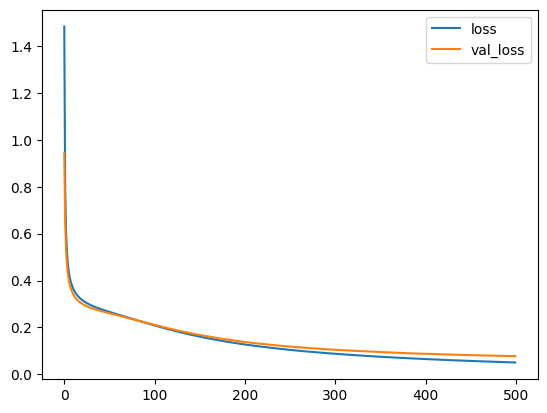

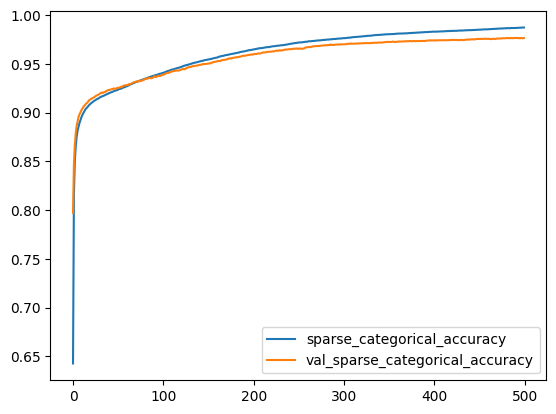

In [9]:
# Prikaz grafika
plt.clf()
plt.plot(history['loss'], label='loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.clf()
plt.plot(history['accuracy'], label='sparse_categorical_accuracy')
plt.plot(history['val_accuracy'], label='val_sparse_categorical_accuracy')
plt.legend()
plt.show()